<a href="https://colab.research.google.com/github/crahulnaidu/recursive-self-improving-ai/blob/main/month_1/ai_month_1_day_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

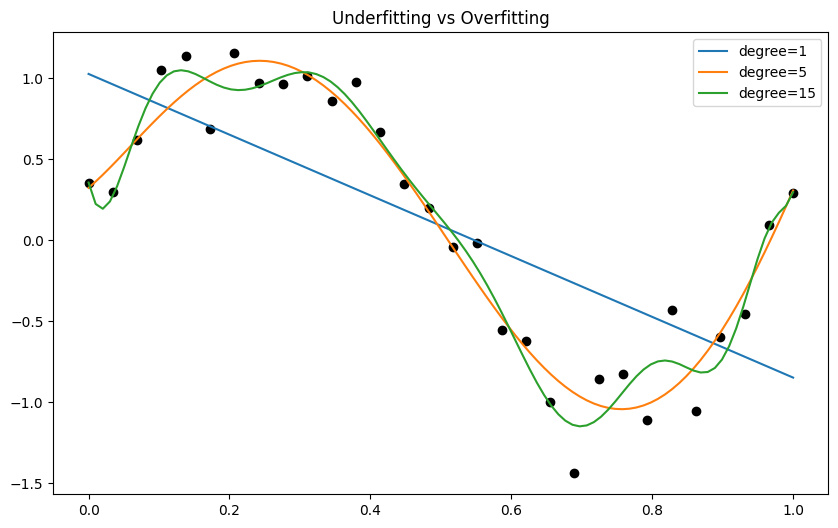

In [6]:
np.random.seed(0)
X=np.linspace(0,1,30).reshape(-1,1)
Y=np.sin(2*np.pi*X)+0.2*np.random.randn(30,1)

degrees=[1,5,15]

plt.figure(figsize=(10,6))
for deg in degrees:
  poly=PolynomialFeatures(deg)
  X_poly=poly.fit_transform(X)

  model=LinearRegression()
  model.fit(X_poly,Y)

  X_test=np.linspace(0,1,100).reshape(-1,1)
  X_test_poly=poly.fit_transform(X_test)

  y_pred=model.predict(X_test_poly)

  plt.plot(X_test,y_pred,label=f"degree={deg}")


plt.scatter(X,Y,color='black')
plt.title("Underfitting vs Overfitting")
plt.legend()
plt.show()


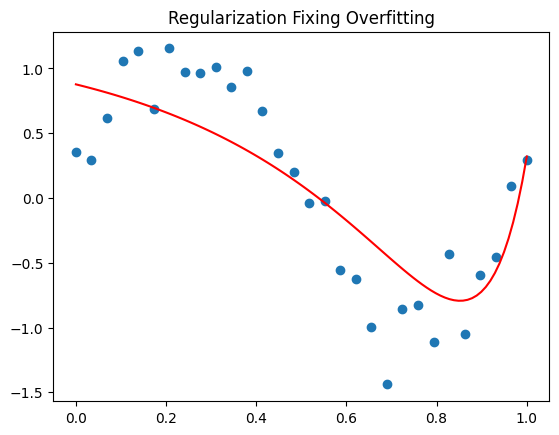

In [17]:
from sklearn.linear_model import Ridge

poly = PolynomialFeatures(degree=15)
X_poly = poly.fit_transform(X)

model = Ridge(alpha=0.7)
model.fit(X_poly, Y)

X_test = np.linspace(0,1,100).reshape(-1,1)
X_test_poly = poly.transform(X_test)

y_pred = model.predict(X_test_poly)

plt.scatter(X, Y)
plt.plot(X_test, y_pred, color='red')
plt.title("Regularization Fixing Overfitting")
plt.show()

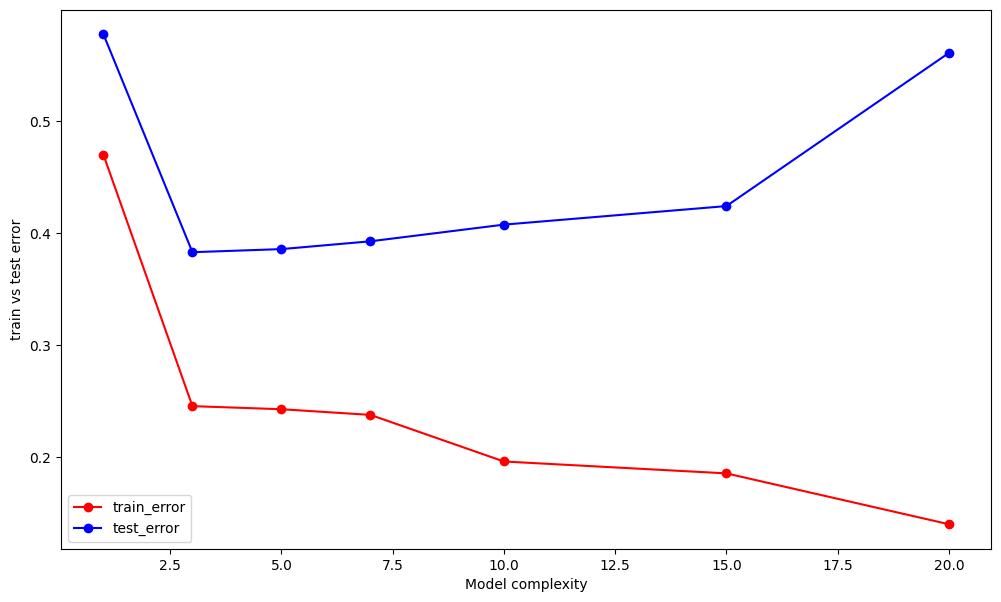

In [30]:
#Model complexity explorer

degree=[1, 3, 5, 7, 10, 15, 20]

X=np.linspace(0,1,40).reshape(-1,1)
Y=np.sin(2*np.pi*X)+0.6*np.random.randn(40,1)

X_test=np.linspace(0,1,100).reshape(-1,1)
Y_test=np.sin(2*np.pi*X_test)+0.6*np.random.randn(100,1)

train_error=[]
test_error=[]

for deg in degree:
  poly=PolynomialFeatures(deg)
  X_poly=poly.fit_transform(X)
  X_test_poly=poly.fit_transform(X_test)

  model=LinearRegression()
  model.fit(X_poly,Y)

  y_pred_train=model.predict(X_poly)
  y_pred_test=model.predict(X_test_poly)

  train_error.append(np.mean((y_pred_train-Y)**2))
  test_error.append(np.mean((y_pred_test-Y_test)**2))



plt.figure(figsize=(12,7))

plt.plot(degree,train_error,color='red',marker='o',label='train_error')
plt.plot(degree,test_error,color='blue',marker='o',label='test_error')
plt.xlabel("Model complexity")
plt.ylabel("train vs test error")
plt.legend()
plt.show()







